# Feature selection integration benchmark

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
import seaborn as sns
import warnings
warnings.simplefilter('ignore', np.polynomial.polyutils.RankWarning)

plt.rcParams["svg.fonttype"] = "none"

from scatlastb_utils.io import read_anndata

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
figure_dir = Path('figures/figure5/tradeoff')
figure_dir.mkdir(exist_ok=True, parents=True)

In [3]:
def get_metrics_df(adata):
    df = pd.concat([adata.uns[key] for key in adata.uns if 'metrics--' in key])
    
    file_id_parsed = df['file_id'].str.split("--") \
        .apply(lambda x: dict(i.split("=") for i in x if "=" in i)) \
        .apply(pd.Series)
    df[file_id_parsed.columns] = file_id_parsed
    
    df["n_top_genes"] = df["n_hvg"].astype(int)
    df["strategy"] = df["strategy"].map({'extra_hvg': 'custom hvgs', 'hvg': 'default hvgs'})
    df["score_scaled"] = (
        # df.groupby(["strategy", "metric"])["score"]
        df.groupby(["metric"])["score"]
          .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
    )
    return df

In [4]:
def plot_tradeoff(
    df,
    x,
    y,
    xlim=(-.1, 1.1),
    ylim=(-.1, 1.1),
    highlight_query=None,
    circle_size=400,
    return_plot=False,
    save=None,
    figsize=(4, 3.5),
    **kwargs
):
    width, height = figsize
    kwargs = dict(
        # hue="Overall score",
        hue='n_top_genes',
        size='n_top_genes',
        style="strategy",
        kind="scatter",
        legend='full',
        palette='viridis',
        sizes=(50, 200),
        height=height,
        aspect=width / height,
    ) | kwargs
    
    g = sns.relplot(data=df, x=x, y=y, **kwargs)
    g.set(xlim=xlim, ylim=ylim)

    # Format legend values: round hue and size
    for text in g._legend.texts:
        try:
            val = float(text.get_text())
            text.set_text(f"{int(val)}" if val.is_integer() else f"{val:.2f}")
        except ValueError:
            # keep non-numeric labels (e.g., strategy names) as-is
            pass

    if highlight_query:
        for ax in g.axes.flatten():
        # mark selected feature selection strategy
            highlight = df.query(highlight_query)
            ax.scatter(
                highlight[x],
                highlight[y],
                s=circle_size,       # marker size
                facecolors="none",   # no fill
                edgecolors="red",    # red outline
                linewidth=2,         # thickness of outline
                zorder=10            # on top
            )
    
    if save:
        plt.savefig(save)
    
    plt.show()
    
    if return_plot:
        return g

In [5]:
def plot_lm(
    data,
    x,
    y,
    ylim=(-.1, 1.1),
    save=None,
    **kwargs,
):
    kwargs = dict(
        aspect=2,
        height=2,
        facet_kws=dict(
            sharex=False,
            sharey=False,
        )
    ) | kwargs
    
    g = sns.lmplot(
        data=data,
        x=x,
        y=y,
        **kwargs
    )
    g.set(ylim=ylim)
    
    if save:
        plt.savefig(save)
    
    plt.show()

In [6]:
def get_summary(
    metrics_df,
    value="score_scaled",
    batch_weight=0.5,
):
    hue = 'metric_type_nice'
    group_cols = ["integration_method", "strategy", "n_top_genes"]

    # nicer metric type names
    metrics_df[hue] = metrics_df['metric_type'].map(
        {
            'bio_conservation': 'Bio conservation',
            'batch_correction': 'Batch correction',
        }
    )

    summary = (
        metrics_df.groupby(group_cols+[hue])[value]
              .mean()
              .unstack(hue)
              .reset_index()
        )
    
    # calculate weighted overall score
    summary['Overall score'] = (
        batch_weight * summary['Batch correction']
        + (1 - batch_weight) * summary['Bio conservation']
    )
    
    summary_long = summary.melt(
        id_vars=group_cols,
        value_vars=["Batch correction", "Bio conservation", 'Overall score'],
        var_name="metric_type",
        value_name="score"
    )
    
    return summary, summary_long

In [7]:
extra_hvg = "custom hvgs"

In [8]:
summaries = {}

## B cells

In [9]:
lineage = 'B_plasma'

In [10]:
adata = read_anndata(
    f'data/pipeline/input/hca_out/majority_voting/dataset~Benchmark_n_hvg_{lineage}/file_id~collect:Benchmark_n_hvg_{lineage}.zarr/',
    uns='uns',
    select_keys='metrics--',
)

dask: False, backed: False
Read slot "uns", store as "uns"...
select only slots that match metrics--


Read uns slots as_dask=False: 100%|██████████| 10/10 [00:01<00:00,  7.19it/s]

shape: (0, 0)


In [11]:
metrics_df = get_metrics_df(adata)

### Summary stats

In [12]:
summary, summary_long = get_summary(metrics_df)
summaries[lineage] = summary_long

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


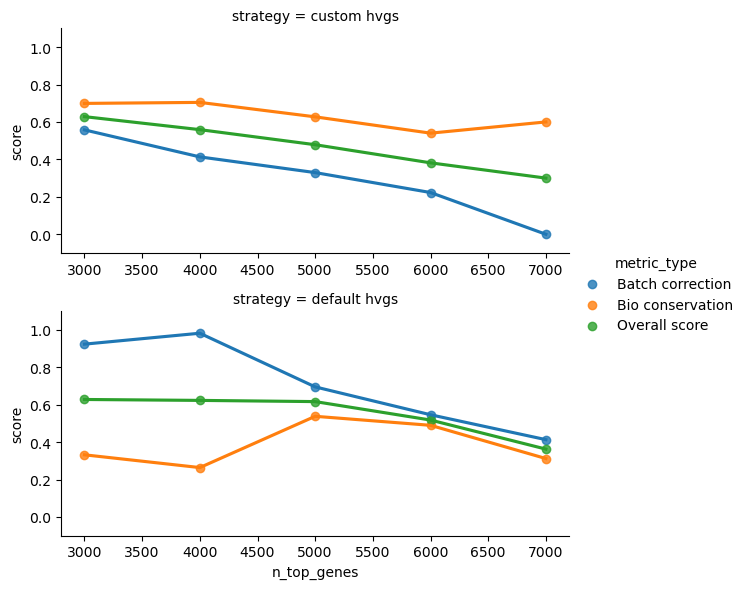

In [13]:
g = sns.lmplot(
    data=summary_long,
    x="n_top_genes",
    y="score",
    hue="metric_type",
    row='strategy',
    aspect=2,
    height=3,
    lowess=True,
    sharex=False
)
g.set(ylim=(-.1, 1.1))
plt.show()

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


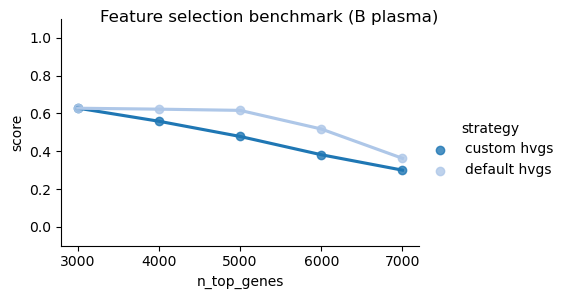

In [14]:
g = sns.lmplot(
    data=summary_long.query('metric_type == "Overall score"'),
    x="n_top_genes",
    y="score",
    hue='strategy',
    aspect=1.5,
    height=3,
    lowess=True,
    sharex=False,
    palette='tab20',
)
g.set(ylim=(-.1, 1.1))
plt.suptitle('Feature selection benchmark (B plasma)')
plt.show()

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


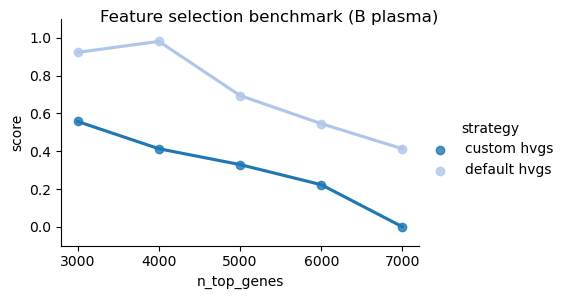

In [15]:
g = sns.lmplot(
    data=summary_long.query('metric_type == "Batch correction"'),
    x="n_top_genes",
    y="score",
    hue='strategy',
    aspect=1.5,
    height=3,
    lowess=True,
    sharex=False,
    palette='tab20',
)
g.set(ylim=(-.1, 1.1))
plt.suptitle('Feature selection benchmark (B plasma)')
plt.show()

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


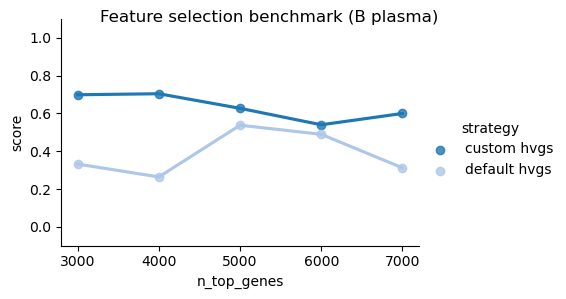

In [16]:
g = sns.lmplot(
    data=summary_long.query('metric_type == "Bio conservation"'),
    x="n_top_genes",
    y="score",
    hue='strategy',
    aspect=1.5,
    height=3,
    lowess=True,
    sharex=False,
    palette='tab20',
)
g.set(ylim=(-.1, 1.1))
plt.suptitle('Feature selection benchmark (B plasma)')
plt.show()

### Ext Fig 4B

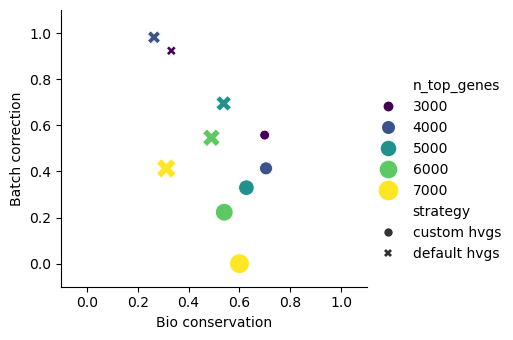

In [17]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    # highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
    save=figure_dir / 'n_hvg_B_tradeoff.svg',
)

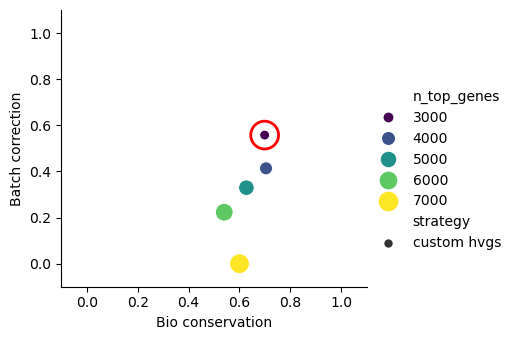

In [18]:
plot_tradeoff(
    df=summary.query('strategy == @extra_hvg'),
    x="Bio conservation",
    y="Batch correction",
    highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
    save=figure_dir / 'n_hvg_B_tradeoff_custom.svg',
)

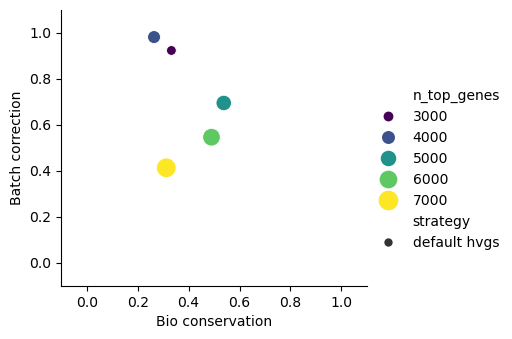

In [19]:
plot_tradeoff(
    df=summary.query('strategy == "default hvgs"'),
    x="Bio conservation",
    y="Batch correction",
    highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
)

In [20]:
summary.to_csv(
    'data/output/HICA/n_hvg_B_summary.tsv',
    sep='\t',
    index=False,
)

### Supp Fig 10

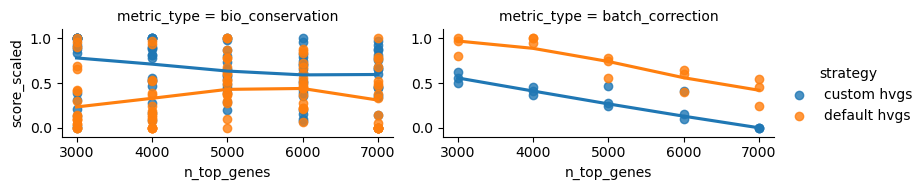

In [21]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df,
    col="metric_type",
    hue="strategy",
    lowess=True,
    save=figure_dir / 'n_hvg_B_metrics_vs_nhvg.svg',
)

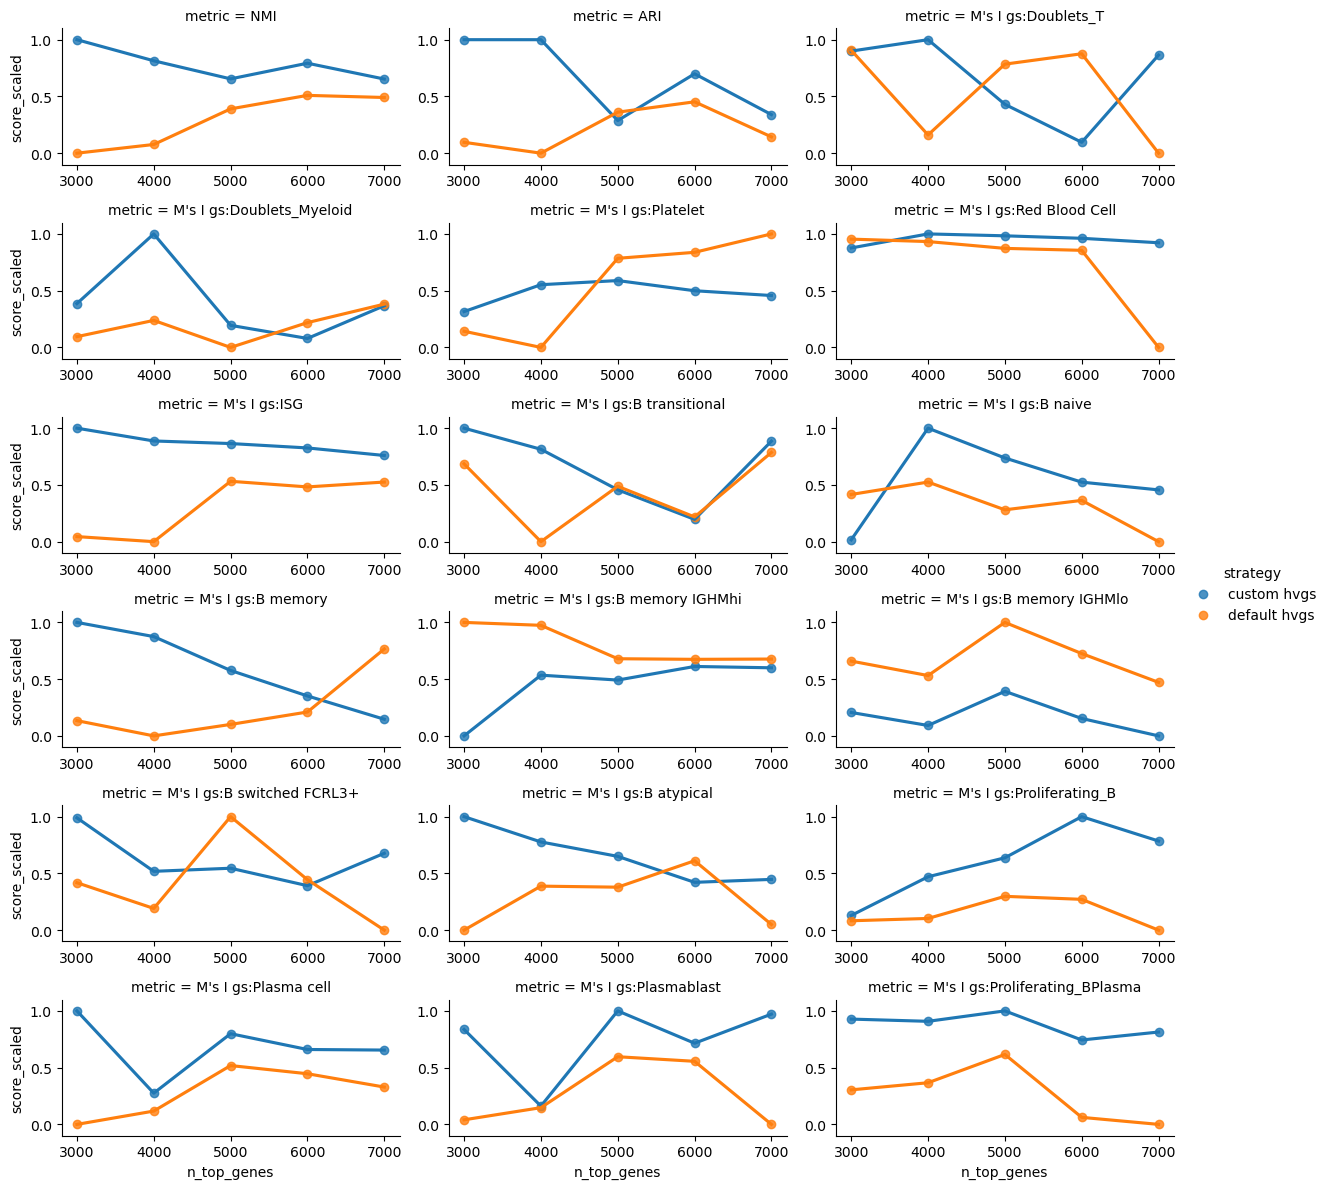

In [22]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df.query('metric_type == "bio_conservation"'),
    hue="strategy",
    col="metric",
    col_wrap=3,
    lowess=True,
    save=figure_dir / 'n_hvg_B_bio_metrics_vs_nhvg.svg',
)

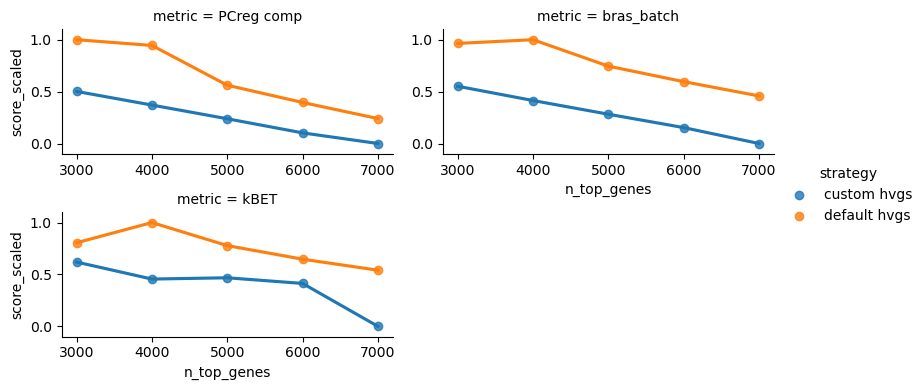

In [23]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df.query('metric_type == "batch_correction"'),
    hue="strategy",
    col="metric",
    col_wrap=2,
    lowess=True,
    save=figure_dir / 'n_hvg_B_batch_metrics_vs_nhvg.svg',
)

## Myeloid

In [24]:
lineage = 'Myeloid'

In [25]:
adata = read_anndata(
    f'data/pipeline/input/hca_out/majority_voting/dataset~Benchmark_n_hvg_{lineage}/file_id~collect:Benchmark_n_hvg_{lineage}.zarr',
    uns='uns',
    select_keys='metrics--',
)

dask: False, backed: False
Read slot "uns", store as "uns"...
select only slots that match metrics--


Read uns slots as_dask=False: 100%|██████████| 10/10 [00:01<00:00,  7.62it/s]

shape: (0, 0)


In [26]:
metrics_df = get_metrics_df(adata)

In [27]:
metrics_df

,metric,metric_type,batch,label,file_id,dataset,integration_batch,integration_hyperparams,integration_label,integration_method,...,max_pss,io_in,io_out,mean_load,cpu_time,file_name,strategy,n_hvg,n_top_genes,score_scaled
0,NMI,bio_conservation,library_id,harmonized_cellhint,harmony--strategy=extra_hvg--n_hvg=3000,Benchmark_n_hvg_Myeloid,library_id,c606b8bfe0,NaN,harmony_pytorch,...,3265.85,214.84,0.19,40.14,11.70,harmony,custom hvgs,3000,3000,0.437111
1,ARI,bio_conservation,library_id,harmonized_cellhint,harmony--strategy=extra_hvg--n_hvg=3000,Benchmark_n_hvg_Myeloid,library_id,c606b8bfe0,NaN,harmony_pytorch,...,3269.78,269.64,0.19,39.49,11.49,harmony,custom hvgs,3000,3000,0.351868
2,PCreg comp,batch_correction,library_id,harmonized_cellhint,harmony--strategy=extra_hvg--n_hvg=3000,Benchmark_n_hvg_Myeloid,library_id,c606b8bfe0,NaN,harmony_pytorch,...,2125.22,69.35,0.19,55.76,11.44,harmony,custom hvgs,3000,3000,0.873278
3,M's I gs:Doublets_B,bio_conservation,library_id,harmonized_cellhint,harmony--strategy=extra_hvg--n_hvg=3000,Benchmark_n_hvg_Myeloid,library_id,c606b8bfe0,NaN,harmony_pytorch,...,5255.21,979.77,0.00,25.35,11.54,harmony,custom hvgs,3000,3000,0.519734
4,M's I gs:Doublets_T,bio_conservation,library_id,harmonized_cellhint,harmony--strategy=extra_hvg--n_hvg=3000,Benchmark_n_hvg_Myeloid,library_id,c606b8bfe0,NaN,harmony_pytorch,...,5255.21,979.77,0.00,25.35,11.54,harmony,custom hvgs,3000,3000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,M's I gs:cDC3,bio_conservation,library_id,harmonized_cellhint,harmony--strategy=hvg--n_hvg=7000,Benchmark_n_hvg_Myeloid,library_id,c606b8bfe0,NaN,harmony_pytorch,...,3390.46,1187.94,0.00,19.24,8.79,harmony,default hvgs,7000,7000,0.295128
14,M's I gs:ASDC,bio_conservation,library_id,harmonized_cellhint,harmony--strategy=hvg--n_hvg=7000,Benchmark_n_hvg_Myeloid,library_id,c606b8bfe0,NaN,harmony_pytorch,...,3390.46,1187.94,0.00,19.24,8.79,harmony,default hvgs,7000,7000,0.000000
15,M's I gs:pDC,bio_conservation,library_id,harmonized_cellhint,harmony--strategy=hvg--n_hvg=7000,Benchmark_n_hvg_Myeloid,library_id,c606b8bfe0,NaN,harmony_pytorch,...,3390.46,1187.94,0.00,19.24,8.79,harmony,default hvgs,7000,7000,0.542715
16,bras_batch,batch_correction,library_id,harmonized_cellhint,harmony--strategy=hvg--n_hvg=7000,Benchmark_n_hvg_Myeloid,library_id,c606b8bfe0,NaN,harmony_pytorch,...,3390.46,1187.94,0.00,19.24,8.79,harmony,default hvgs,7000,7000,0.000000


### Summary stats

In [28]:
summary, summary_long = get_summary(metrics_df)
summaries[lineage] = summary_long

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


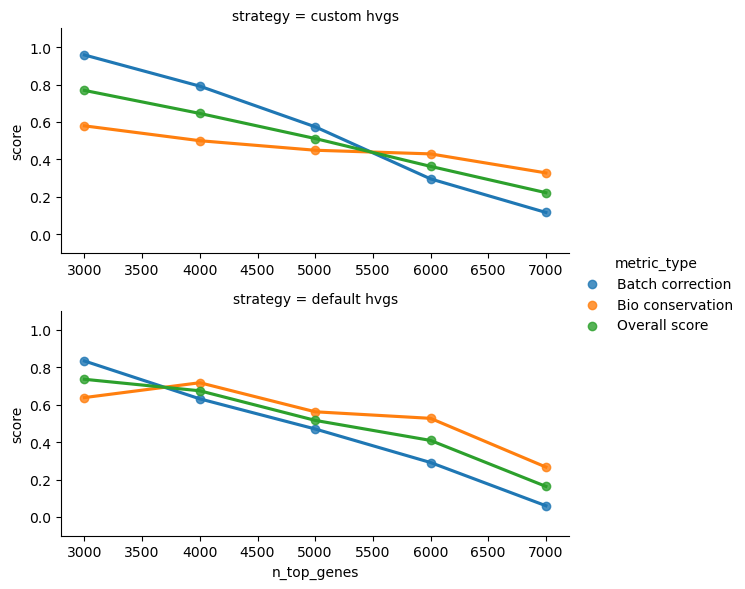

In [29]:
g = sns.lmplot(
    data=summary_long,
    x="n_top_genes",
    y="score",
    hue="metric_type",
    row='strategy',
    aspect=2,
    height=3,
    lowess=True,
    sharex=False
)
g.set(ylim=(-.1, 1.1))
plt.show()

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


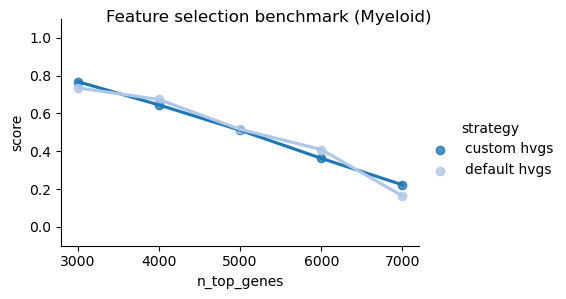

In [30]:
g = sns.lmplot(
    data=summary_long.query('metric_type == "Overall score"'),
    x="n_top_genes",
    y="score",
    hue='strategy',
    aspect=1.5,
    height=3,
    lowess=True,
    sharex=False,
    palette='tab20',
)
g.set(ylim=(-.1, 1.1))
plt.suptitle('Feature selection benchmark (Myeloid)')
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


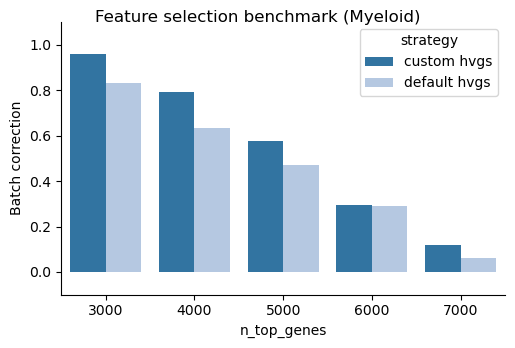

In [31]:
metric = "Batch correction"
g = sns.catplot(
    data=summary_long.query('metric_type == @metric'),
    x="n_top_genes",
    y="score",
    hue='strategy',
    kind='bar',
    aspect=1.5,
    height=3.5,
    palette='tab20',
    legend_out=False,
)
g.set(ylim=(-.1, 1.1))
g.set_ylabels(metric)
plt.suptitle('Feature selection benchmark (Myeloid)')
plt.show()
g.savefig('data/output/HICA/n_hvg_Myeloid_batch.pdf')

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


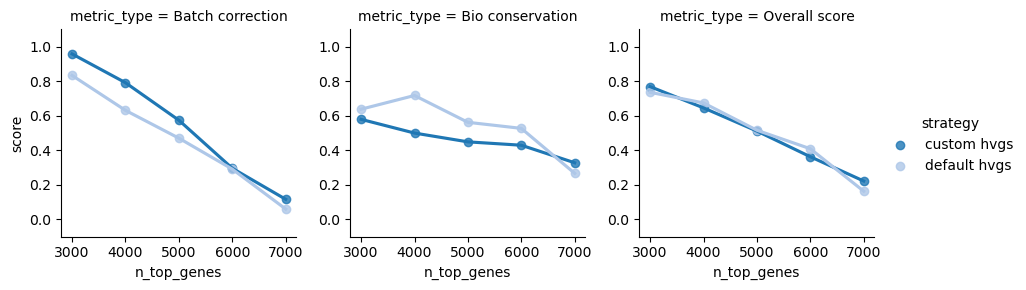

In [32]:
g = sns.lmplot(
    data=summary_long,
    x="n_top_genes",
    y="score",
    col="metric_type",
    hue='strategy',
    aspect=1,
    height=3,
    lowess=True,
    sharey=False,
    palette='tab20',
)
g.set(ylim=(-.1, 1.1))
plt.show()

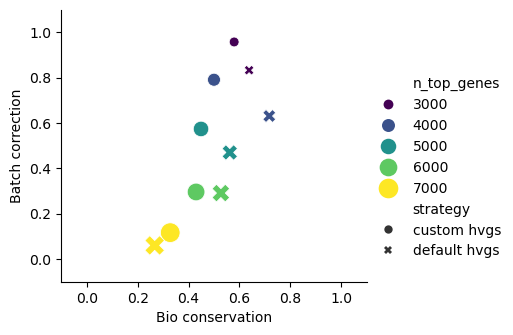

In [33]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    # highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
    save=figure_dir / 'n_hvg_Myeloid_tradeoff.svg',
)

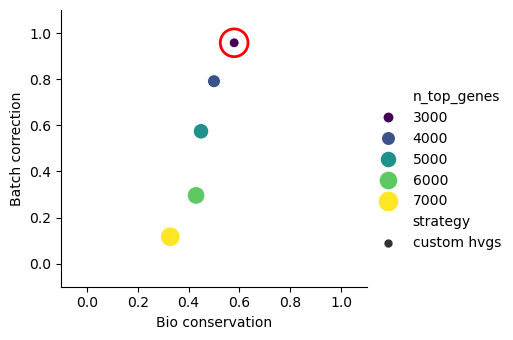

In [34]:
plot_tradeoff(
    df=summary.query('strategy == @extra_hvg'),
    x="Bio conservation",
    y="Batch correction",
    highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
    save=figure_dir / 'n_hvg_Myeloid_tradeoff_custom.svg',
)

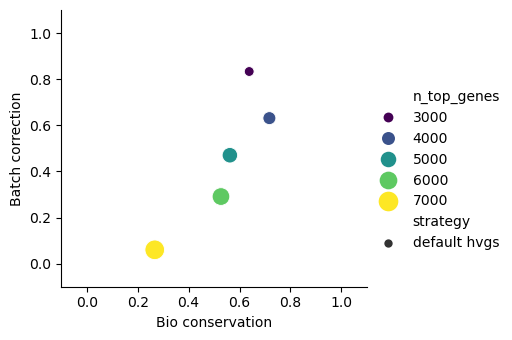

In [35]:
plot_tradeoff(
    df=summary.query('strategy == "default hvgs"'),
    x="Bio conservation",
    y="Batch correction",
    highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
)

In [36]:
summary.to_csv(
    'data/output/HICA/n_hvg_Myeloid_summary.tsv',
    sep='\t',
    index=False,
)

### Model n_top_genes vs all metrics

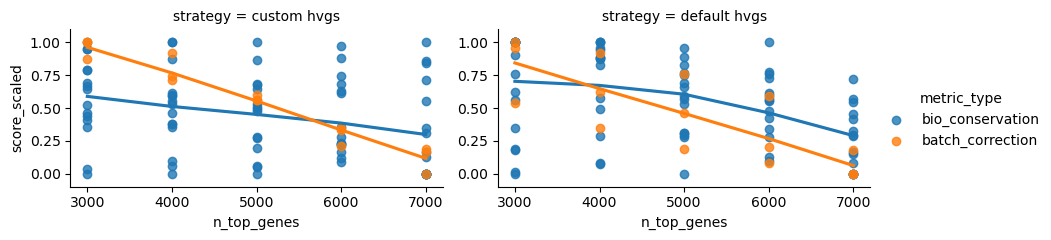

In [37]:
plot_lm(
    metrics_df,
    x="n_top_genes",
    y="score_scaled",
    hue="metric_type",
    col="strategy",
    lowess=True,
    aspect=1.8,
    height=2.5,
)

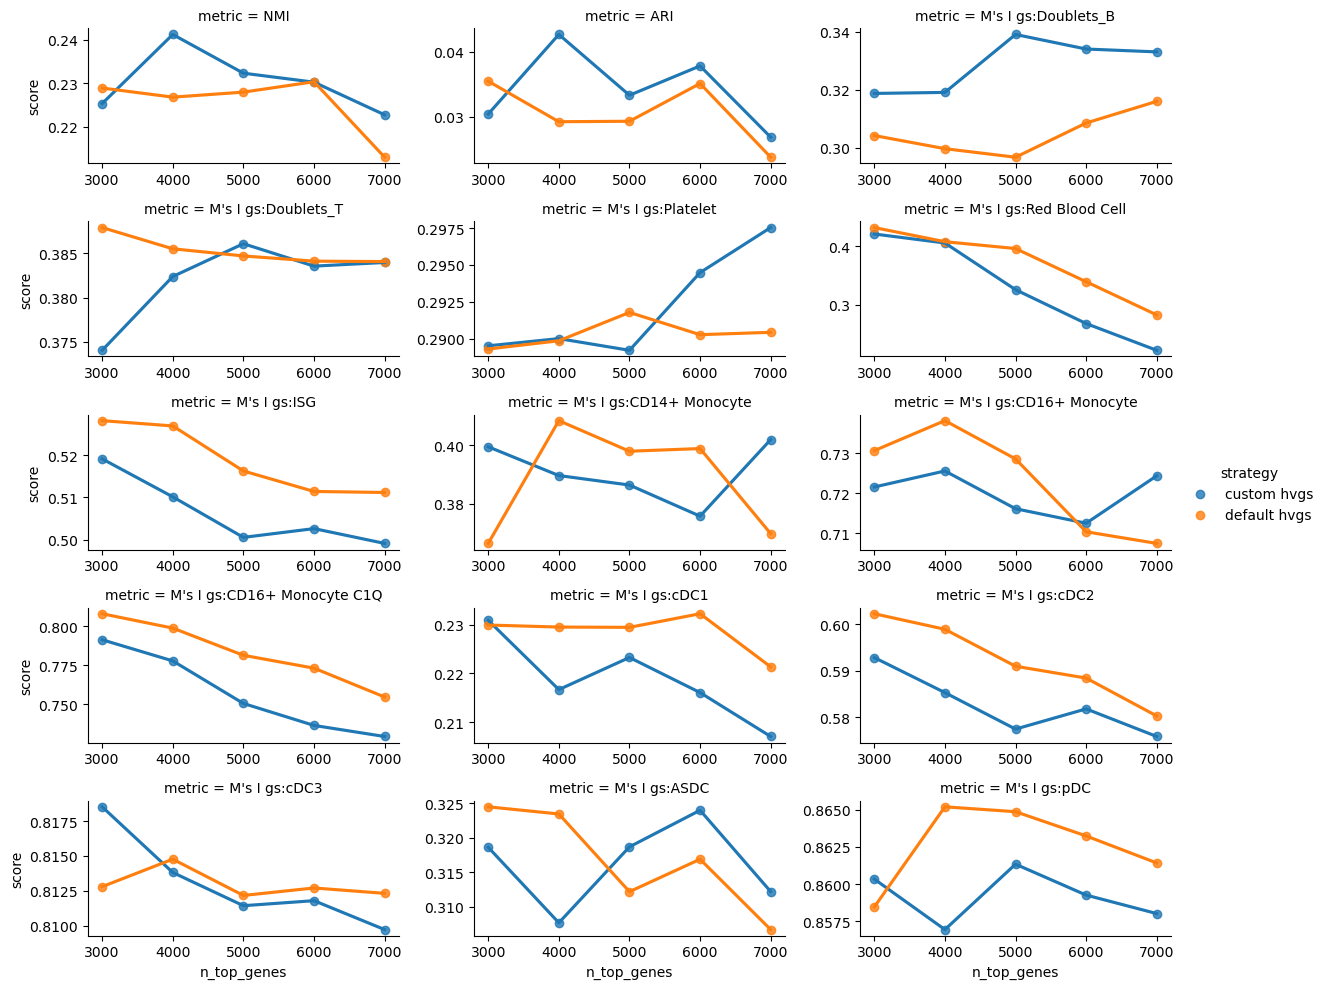

In [38]:
sns.lmplot(
    x="n_top_genes",
    y="score",
    # y="score_scaled",
    data=metrics_df.query('metric_type == "bio_conservation"'),
    hue="strategy",
    col="metric",
    col_wrap=3,
    lowess=True,
    aspect=2,
    height=2,
    facet_kws=dict(
        sharex=False,
        sharey=False,
    ),
)
plt.show()

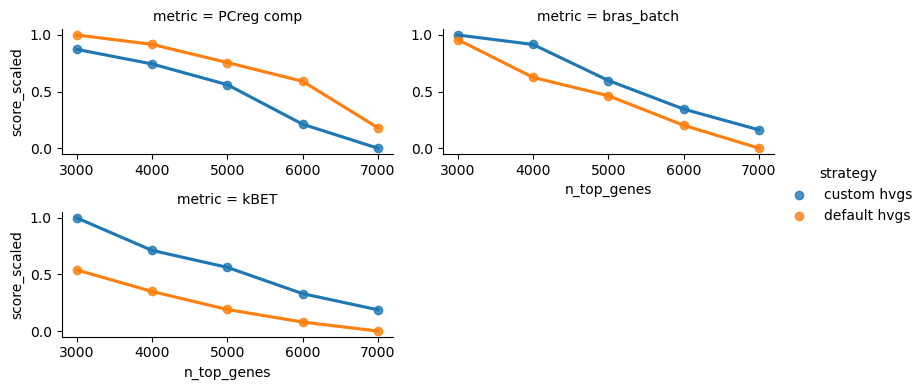

In [39]:
sns.lmplot(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df.query('metric_type == "batch_correction"'),
    hue="strategy",
    col="metric",
    col_wrap=2,
    lowess=True,
    aspect=2,
    height=2,
    facet_kws=dict(
        sharex=False,
        sharey=False,
    ),
)
plt.show()

### Fit slope

In [40]:
slope_map = (
    metrics_df.groupby("metric")
    .apply(
        lambda g: np.polyfit(g["n_top_genes"], g["score_scaled"], 1)[0],
        include_groups=False,
    )
)

metrics_df["slope"] = metrics_df["metric"].map(slope_map)
metrics_df.value_counts(['metric', 'slope'])

metric                       slope    
ARI                          -0.000078    10
M's I gs:ASDC                -0.000109    10
M's I gs:CD14+ Monocyte      -0.000014    10
M's I gs:CD16+ Monocyte      -0.000133    10
M's I gs:CD16+ Monocyte C1Q  -0.000189    10
M's I gs:Doublets_B           0.000090    10
M's I gs:Doublets_T           0.000043    10
M's I gs:ISG                 -0.000167    10
M's I gs:Platelet             0.000139    10
M's I gs:Red Blood Cell      -0.000215    10
M's I gs:cDC1                -0.000124    10
M's I gs:cDC2                -0.000174    10
M's I gs:cDC3                -0.000129    10
M's I gs:pDC                  0.000010    10
NMI                          -0.000079    10
PCreg comp                   -0.000212    10
bras_batch                   -0.000229    10
kBET                         -0.000168    10
Name: count, dtype: int64

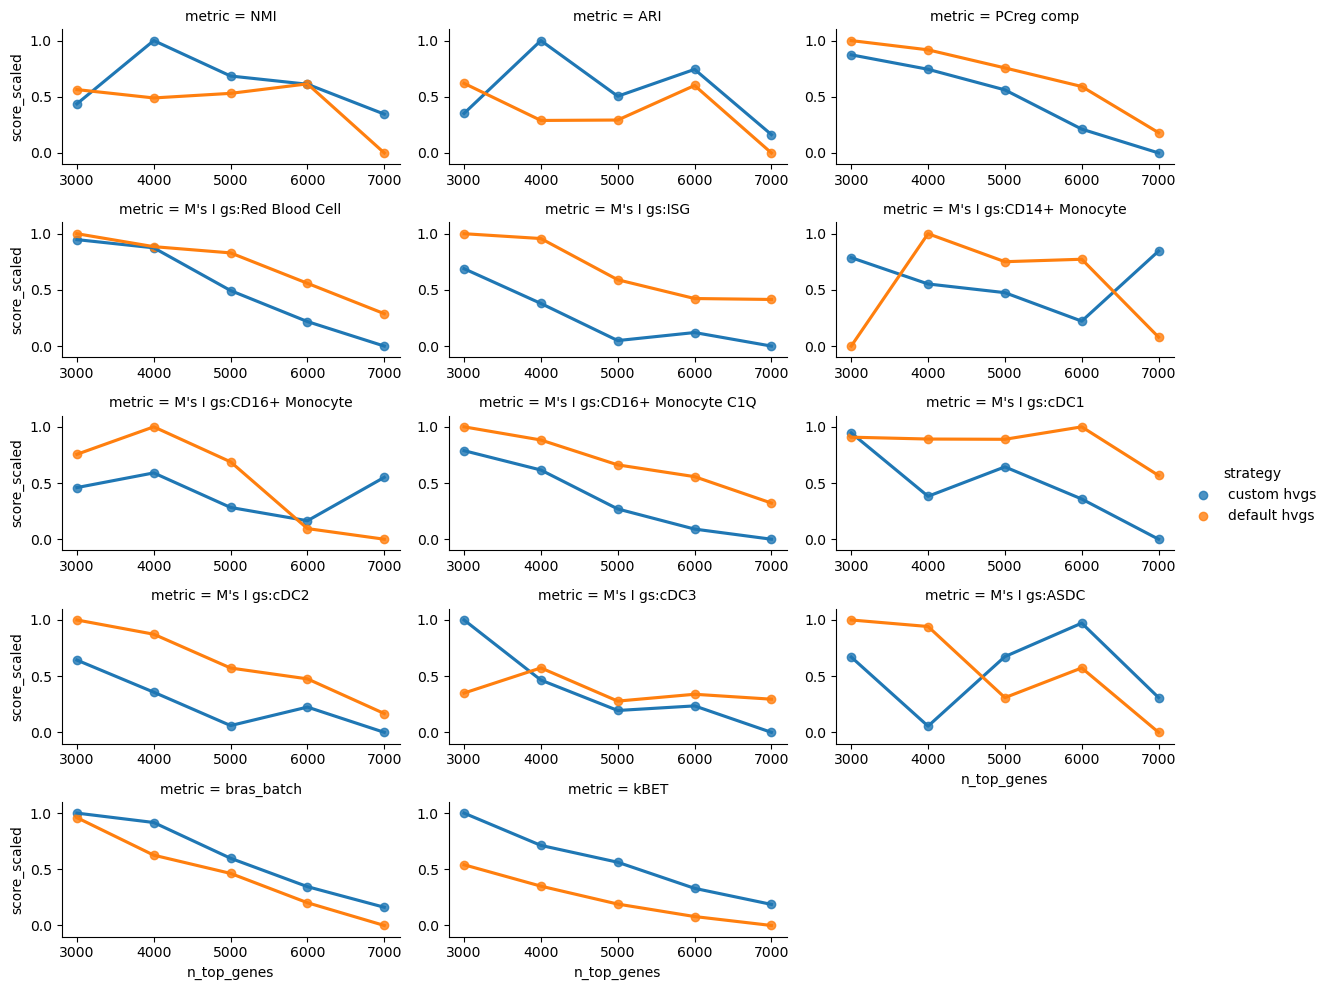

In [41]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df.query('slope < 0'),
    hue="strategy",
    col="metric",
    col_wrap=3,
    lowess=True,
)

## TCD8

In [42]:
lineage = 'TCD8_NK'

In [43]:
adata = read_anndata(
    f'data/pipeline/input/hca_out/majority_voting/dataset~Benchmark_n_hvg_{lineage}/file_id~collect:Benchmark_n_hvg_{lineage}.zarr/',
    uns='uns',
    select_keys='metrics--',
)

dask: False, backed: False
Read slot "uns", store as "uns"...
select only slots that match metrics--


Read uns slots as_dask=False: 100%|██████████| 10/10 [00:01<00:00,  7.80it/s]

shape: (0, 0)


In [44]:
metrics_df = get_metrics_df(adata)

### Summary stats

In [45]:
summary, summary_long = get_summary(metrics_df)
summaries[lineage] = summary_long

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


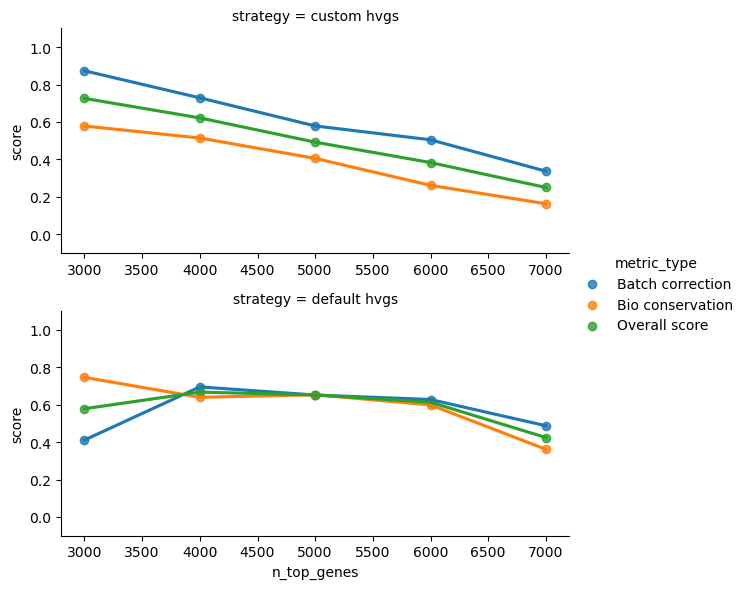

In [46]:
g = sns.lmplot(
    data=summary_long,
    x="n_top_genes",
    y="score",
    hue="metric_type",
    row='strategy',
    # kind='line',
    # marker='o',
    aspect=2,
    height=3,
    lowess=True,
    sharex=False,
)
g.set(ylim=(-.1, 1.1))
plt.show()

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


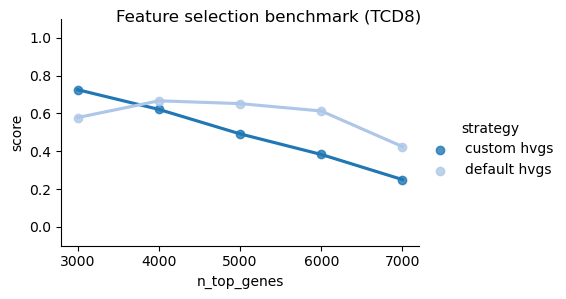

In [47]:
g = sns.lmplot(
    data=summary_long.query('metric_type == "Overall score"'),
    x="n_top_genes",
    y="score",
    hue='strategy',
    aspect=1.5,
    height=3,
    lowess=True,
    sharex=False,
    palette='tab20',
)
g.set(ylim=(-.1, 1.1))
plt.suptitle('Feature selection benchmark (TCD8)')
plt.show()

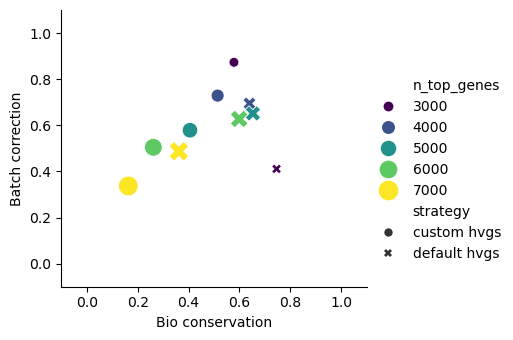

In [48]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    # highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
    save=figure_dir / 'n_hvg_TCD8_tradeoff.svg',
)

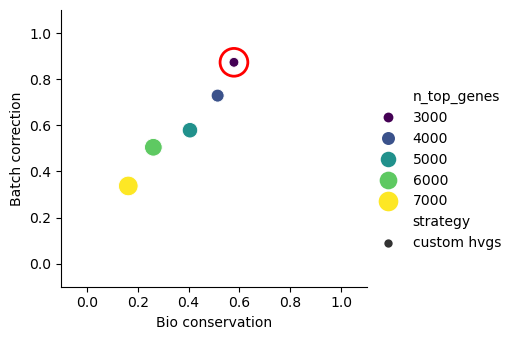

In [49]:
plot_tradeoff(
    df=summary.query('strategy == @extra_hvg'),
    x="Bio conservation",
    y="Batch correction",
    highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
    save=figure_dir / 'n_hvg_TCD8_tradeoff_custom.svg',
)

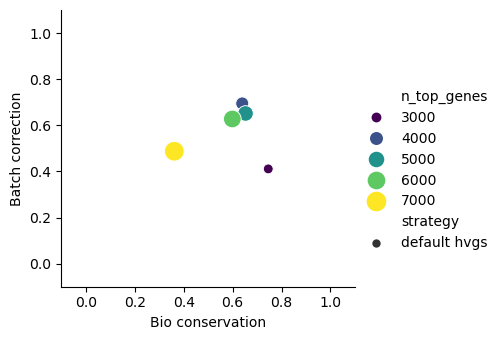

In [50]:
plot_tradeoff(
    df=summary.query('strategy == "default hvgs"'),
    x="Bio conservation",
    y="Batch correction",
    highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
)

In [51]:
summary.to_csv(
    'data/output/HICA/n_hvg_tcd8_summary.tsv',
    sep='\t',
    index=False,
)

### Model n_top_genes vs all metrics

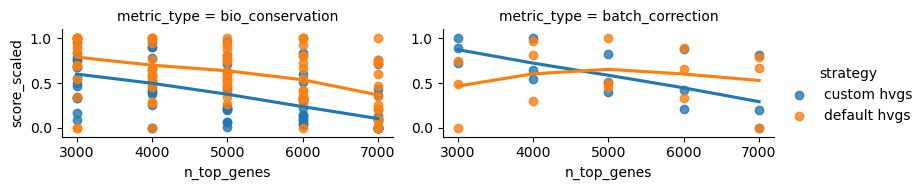

In [52]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df,
    col="metric_type",
    hue="strategy",
    lowess=True,
)

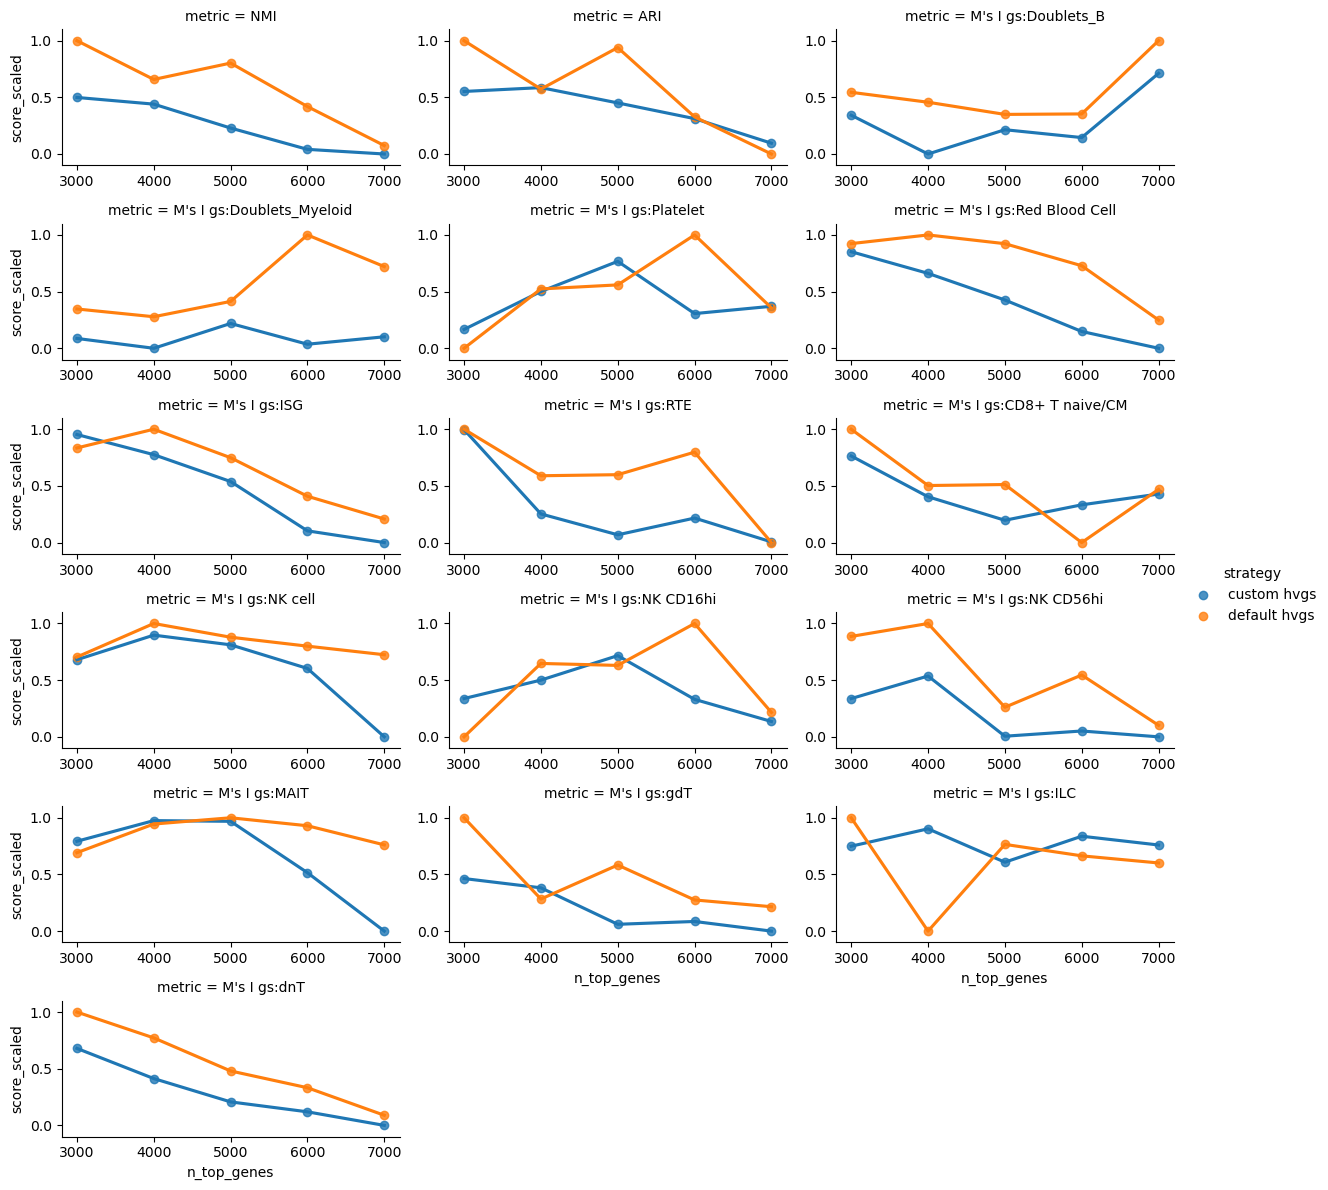

In [53]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df.query('metric_type == "bio_conservation"'),
    hue="strategy",
    col="metric",
    col_wrap=3,
    # order=2,
    lowess=True,
)

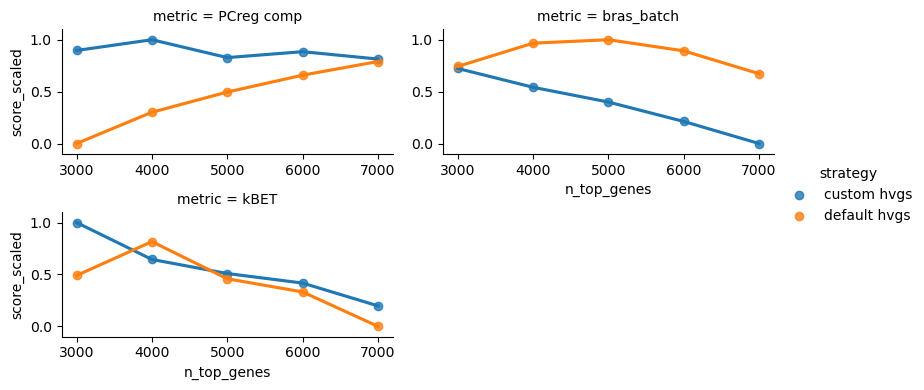

In [54]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df.query('metric_type == "batch_correction"'),
    hue="strategy",
    col="metric",
    col_wrap=2,
    lowess=True,
)

## TCD4

In [55]:
lineage = 'TCD4'

In [56]:
adata = read_anndata(
    f'data/pipeline/input/hca_out/majority_voting/dataset~Benchmark_n_hvg_{lineage}/file_id~collect:Benchmark_n_hvg_{lineage}.zarr/',
    uns='uns',
    select_keys='metrics--',
)

dask: False, backed: False
Read slot "uns", store as "uns"...
select only slots that match metrics--


Read uns slots as_dask=False: 100%|██████████| 10/10 [00:01<00:00,  7.63it/s]

shape: (0, 0)


In [57]:
metrics_df = get_metrics_df(adata)

### Summary stats

In [58]:
summary, summary_long = get_summary(metrics_df)
summaries[lineage] = summary_long

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


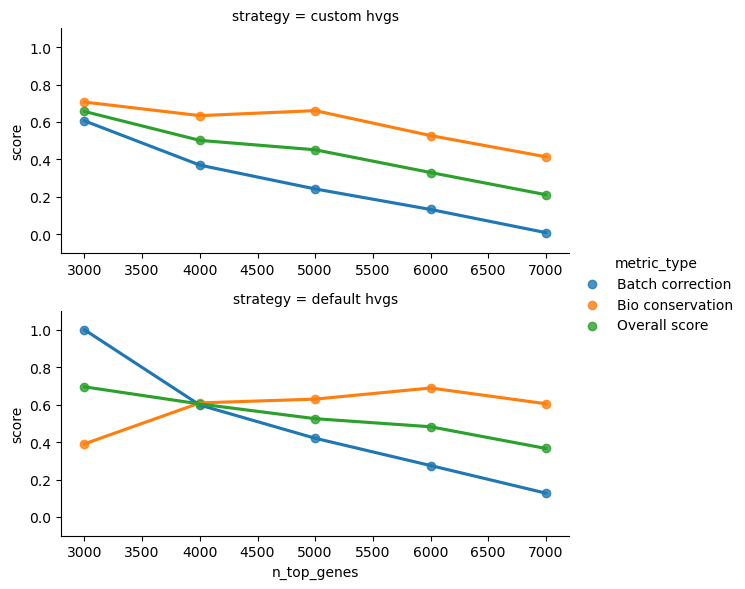

In [59]:
g = sns.lmplot(
    data=summary_long,
    x="n_top_genes",
    y="score",
    hue="metric_type",
    row='strategy',
    aspect=2,
    height=3,
    lowess=True,
    sharex=False,
)
g.set(ylim=(-.1, 1.1))
plt.show()

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


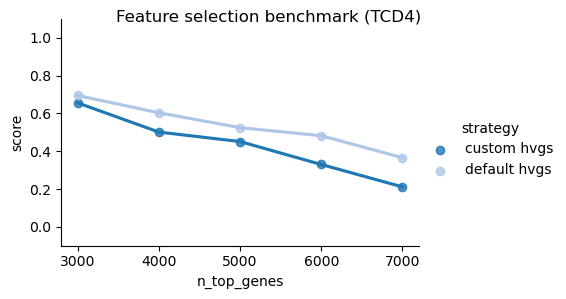

In [60]:
g = sns.lmplot(
    data=summary_long.query('metric_type == "Overall score"'),
    x="n_top_genes",
    y="score",
    hue='strategy',
    aspect=1.5,
    height=3,
    lowess=True,
    sharex=False,
    palette='tab20',
)
g.set(ylim=(-.1, 1.1))
plt.suptitle('Feature selection benchmark (TCD4)')
plt.show()

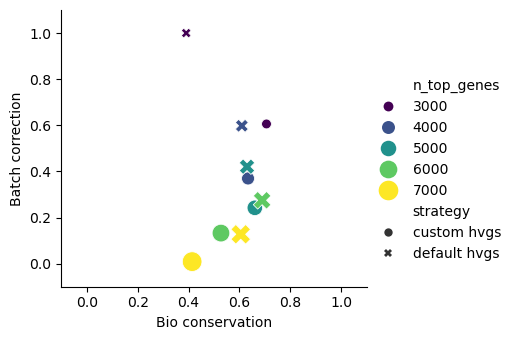

In [61]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    # highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
    save=figure_dir / 'n_hvg_TCD4_tradeoff.svg',
)

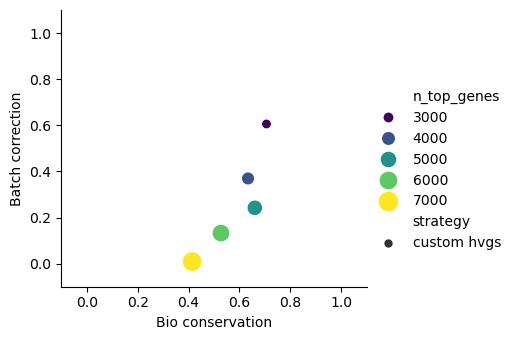

In [62]:
plot_tradeoff(
    df=summary.query('strategy == @extra_hvg'),
    x="Bio conservation",
    y="Batch correction",
    # highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
    save=figure_dir / 'n_hvg_TCD4_tradeoff_custom.svg',
)

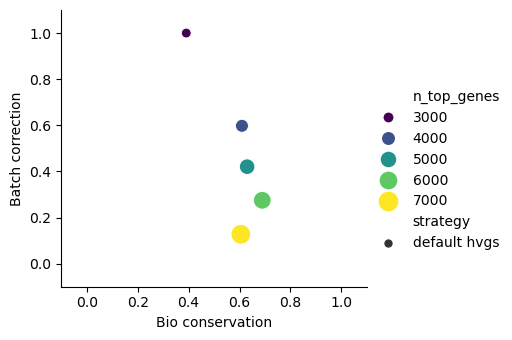

In [63]:
plot_tradeoff(
    df=summary.query('strategy == "default hvgs"'),
    x="Bio conservation",
    y="Batch correction",
    highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
)

In [64]:
summary.to_csv(
    'data/output/HICA/n_hvg_tcd4_summary.tsv',
    sep='\t',
    index=False,
)

### Model n_top_genes vs all metrics

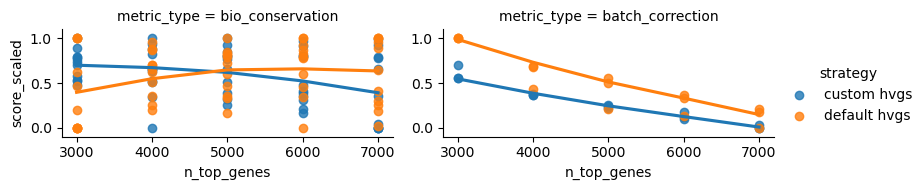

In [65]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df,
    col="metric_type",
    hue="strategy",
    lowess=True,
)

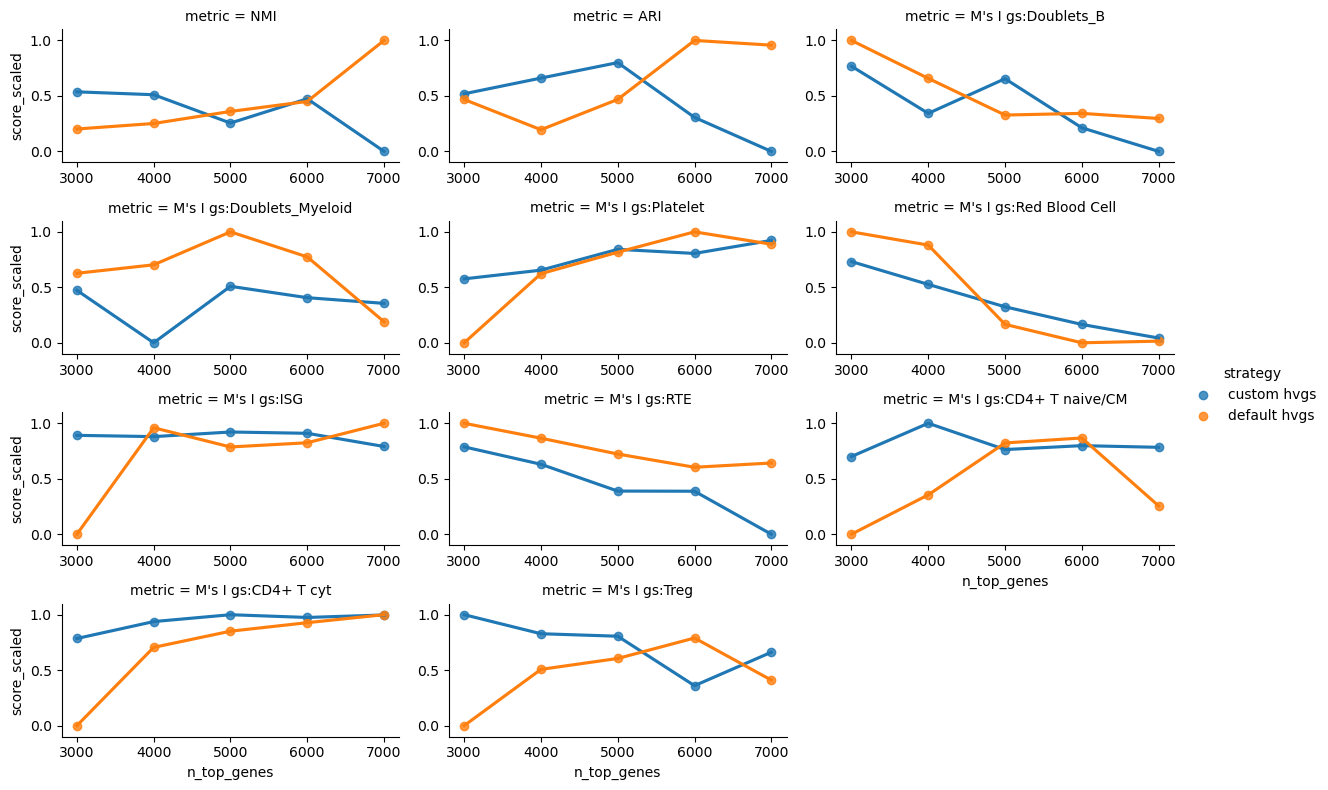

In [66]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df.query('metric_type == "bio_conservation"'),
    hue="strategy",
    col="metric",
    col_wrap=3,
    lowess=True,
)

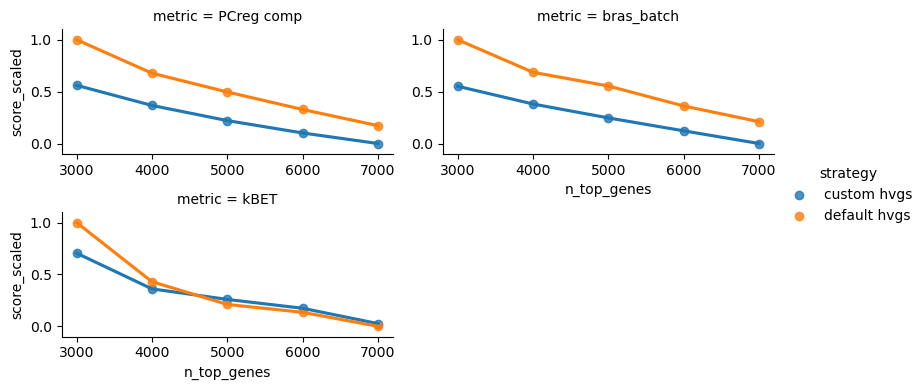

In [67]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df.query('metric_type == "batch_correction"'),
    hue="strategy",
    col="metric",
    col_wrap=2,
    lowess=True,
)

## Global

In [68]:
adata = read_anndata(
    'data/pipeline/input/hca_out/majority_voting/dataset~Benchmark_n_hvg_global/file_id~collect:Benchmark_n_hvg_global.zarr/',
    uns='uns',
    select_keys='metrics--',
)

dask: False, backed: False
Read slot "uns", store as "uns"...
select only slots that match metrics--


Read uns slots as_dask=False: 100%|██████████| 10/10 [00:01<00:00,  8.43it/s]

shape: (0, 0)


In [69]:
metrics_df = get_metrics_df(adata)

### Summary stats

In [70]:
summary, summary_long = get_summary(metrics_df)
summaries[lineage] = summary_long

/hpc/scratch/project.hca_integration/miniforge3/envs/scanpy/lib/python3.11/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


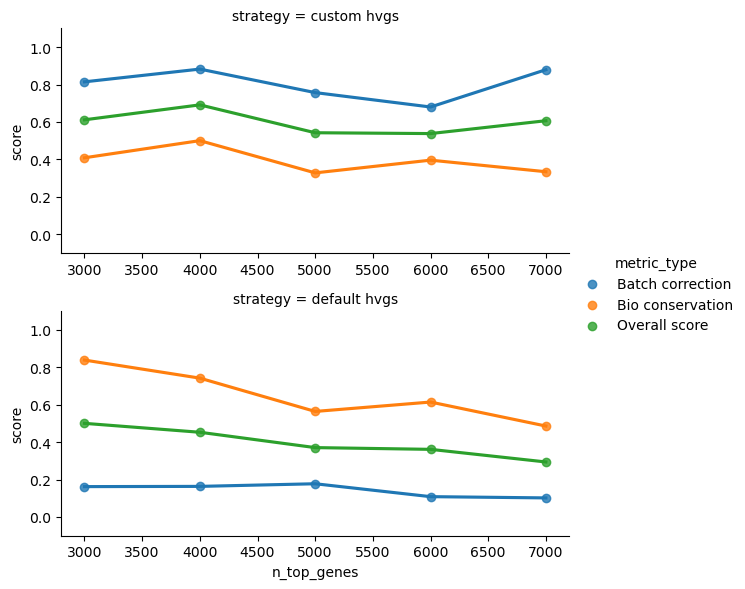

In [71]:
g = sns.lmplot(
    data=summary_long,
    x="n_top_genes",
    y="score",
    hue="metric_type",
    row='strategy',
    aspect=2,
    height=3,
    lowess=True,
    sharex=False,
)
g.set(ylim=(-.1, 1.1))
plt.show()

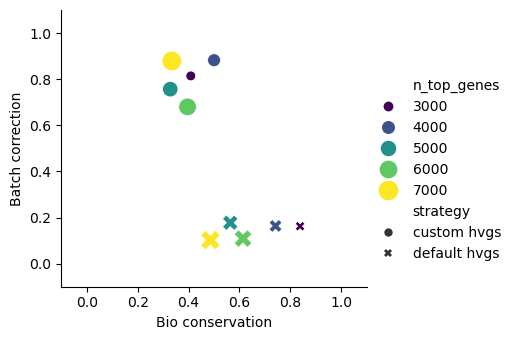

In [72]:
plot_tradeoff(
    df=summary,
    x="Bio conservation",
    y="Batch correction",
    # highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
    save=figure_dir / 'n_hvg_global_tradeoff.svg',
)

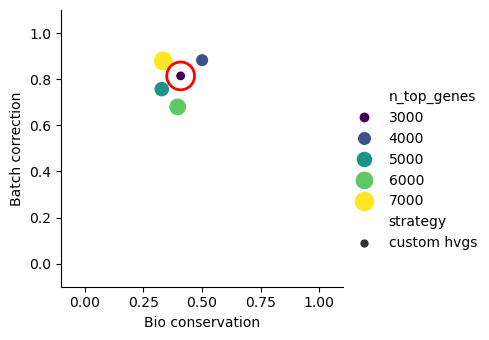

In [73]:
plot_tradeoff(
    df=summary.query('strategy == @extra_hvg'),
    x="Bio conservation",
    y="Batch correction",
    highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
    save=figure_dir / 'n_hvg_global_tradeoff_custom.svg',
)

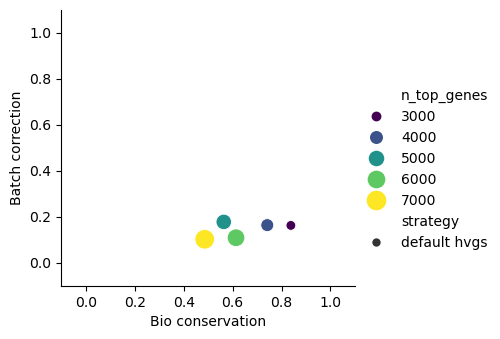

In [74]:
plot_tradeoff(
    df=summary.query('strategy == "default hvgs"'),
    x="Bio conservation",
    y="Batch correction",
    highlight_query="strategy == @extra_hvg and n_top_genes == 3000",
    legend='full',
)

### Model n_top_genes vs all metrics

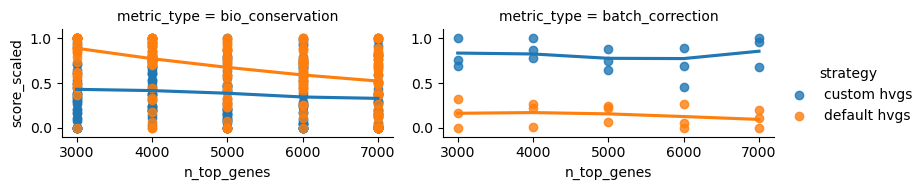

In [75]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df,
    col="metric_type",
    hue="strategy",
    lowess=True,
    x_jitter=1,
)

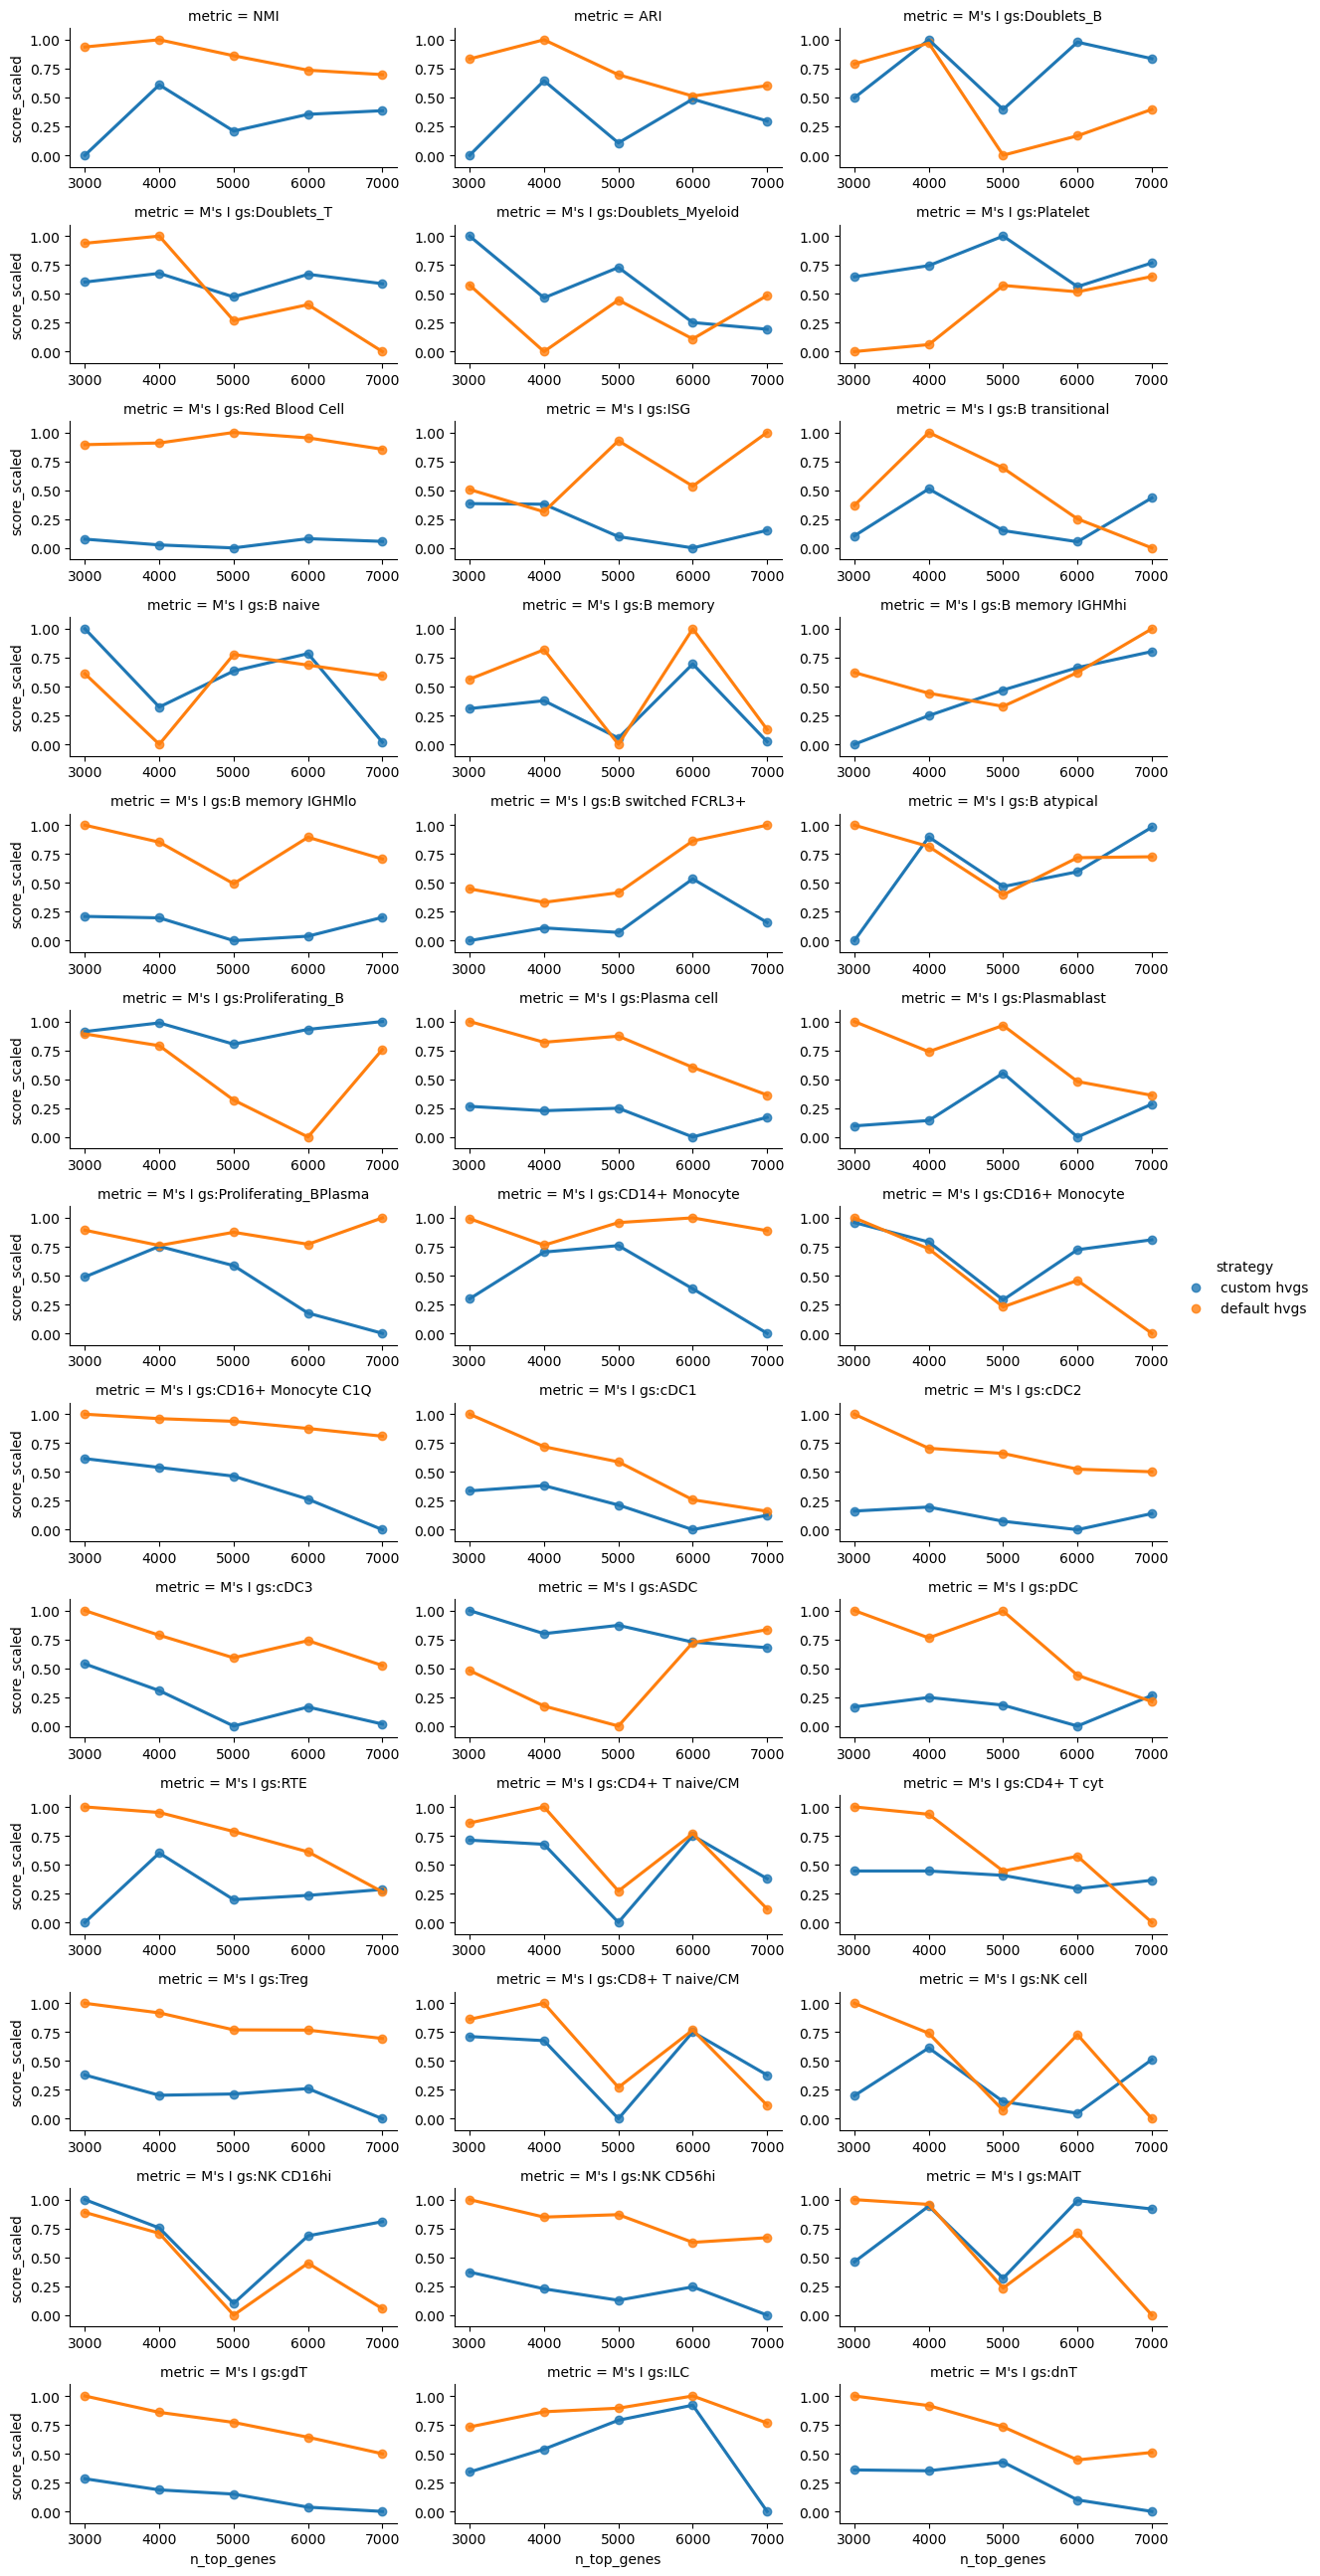

In [76]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df.query('metric_type == "bio_conservation"'),
    hue="strategy",
    col="metric",
    col_wrap=3,
    lowess=True,
)

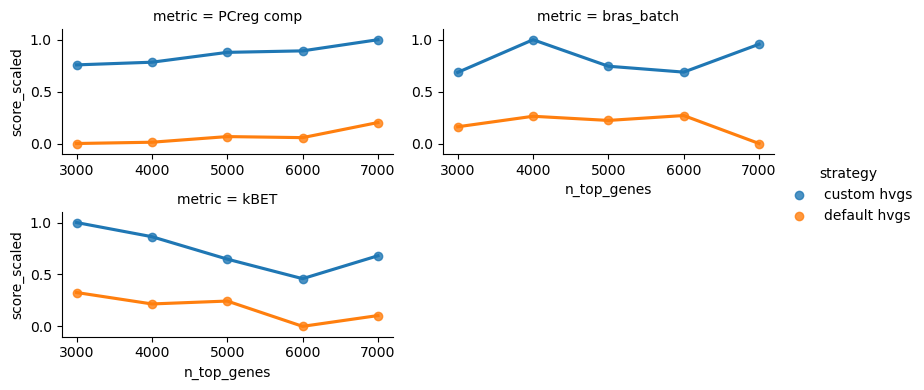

In [77]:
plot_lm(
    x="n_top_genes",
    y="score_scaled",
    data=metrics_df.query('metric_type == "batch_correction"'),
    hue="strategy",
    col="metric",
    col_wrap=2,
    lowess=True,
)